# 信号对比教程

在 `rotation_strategy` 教程中，我们学习了如何用 TopNRanking 信号构建轮动策略。但 TopNRanking 只是 open-xquant 提供的多种**权重信号**之一。

本教程对比三种权重信号在相同条件下的表现差异：

| 信号 | 核心思路 | 适用场景 |
|------|----------|----------|
| **EqualWeight** | 所有资产等权分配 | 没有明确观点，追求分散化 |
| **TopNRanking** | 按评分排名，优选 Top N | 对动量/因子有信心，愿意集中持仓 |
| **RiskParity** | 按波动率倒数分配，低波动多配 | 追求风险均衡，不想被高波动资产主导 |

### 实验设计

**控制变量**：相同标的、相同日期、相同指标、相同调仓频率（10 天）

**自变量**：Signal 层的权重分配方法

```
Universe    → 513100.SS, 510300.SS, 518880.SS
  ↓
Indicator   → mom = Momentum(20)
            → vol = RollingVolatility(20)
            → ram = Ratio(mom / vol)
  ↓
Signal      → ① EqualWeight(max_weight=0.6)
            → ② TopNRanking(score=ram, n=2, max_weight=0.6)
            → ③ RiskParity(vol=vol, max_weight=0.6)
  ↓
Rule        → RebalanceRule(weight_col=tw, frequency=10)
```

### 前置条件

- 已完成 `rotation_strategy` 教程（了解 Indicator → Signal → Rule 流程）
- 已下载数据（参考 `rotation_strategy` 教程第 1 节）

## 1. 准备数据与指标

In [1]:
import pandas as pd

from oxq.data import LocalMarketDataProvider
from oxq.indicators import Momentum, Ratio, RollingVolatility

SYMBOLS = ("513100.SS", "510300.SS", "518880.SS")
SYMBOL_NAMES = {
    "513100.SS": "纳指100ETF",
    "510300.SS": "沪深300ETF",
    "518880.SS": "黄金ETF",
}
START = "2024-11-15"
END = "2026-02-28"

# 加载行情 & 计算指标（与 rotation_strategy 教程完全相同）
market = LocalMarketDataProvider()
mktdata: dict[str, pd.DataFrame] = {}
for sym in SYMBOLS:
    d = market.get_bars(sym, START, END).copy()
    d["mom"] = Momentum().compute(d, column="close", period=20)
    d["vol"] = RollingVolatility().compute(d, column="close", period=20)
    d["ram"] = Ratio().compute(d, col_a="mom", col_b="vol")
    mktdata[sym] = d

print(f"标的: {', '.join(SYMBOL_NAMES[s] for s in SYMBOLS)}")
print(f"区间: {START} ~ {END}")
print(f"每只 ETF 含列: {list(mktdata[SYMBOLS[0]].columns)}")

标的: 纳指100ETF, 沪深300ETF, 黄金ETF
区间: 2024-11-15 ~ 2026-02-28
每只 ETF 含列: ['open', 'high', 'low', 'close', 'volume', 'mom', 'vol', 'ram']


## 2. 三种信号的算法对比

三种信号都接收相同的输入 `mktdata: dict[str, DataFrame]`，返回相同的输出 `dict[str, Series]`（每个 symbol 一条权重序列）。区别在于**如何计算权重**。

| | EqualWeight | TopNRanking | RiskParity |
|---|---|---|---|
| **输入依赖** | 只需 close | 需要评分列（如 ram） | 需要波动率列（如 vol） |
| **筛选逻辑** | 全选（有 close 即可） | 按评分取 Top N | 全选（有 vol 即可） |
| **权重计算** | 1/N 等分 | 评分归一化 | 波动率倒数归一化 |
| **max_weight** | 裁剪，超出归现金 | 裁剪，超出归现金 | 裁剪，超出归现金 |
| **隐含观点** | 无观点 | 动量越强越值得持有 | 波动越低越值得持有 |

### 2.1 EqualWeight — 等权分配

最简单的权重方案：所有有效标的平均分配。

```
每个 bar:
  1. 统计 close 非 NaN 的标的数量 N
  2. 每只标的权重 = min(1/N, max_weight)
  3. close 为 NaN 的标的权重 = 0
```

**特点**：不需要任何指标输入，对所有资产一视同仁。适合作为 baseline 或在没有好的因子时使用。

In [2]:
from oxq.signals import EqualWeight

ew_weights = EqualWeight().compute(mktdata, max_weight=0.6)

ew_df = pd.DataFrame({SYMBOL_NAMES[s]: ew_weights[s] for s in SYMBOLS})
print("EqualWeight 权重（2025年1月）：")
print(ew_df.loc["2025-01-01":"2025-01-31"].to_string(float_format="%.4f"))
print(f"\n每天每只 ETF 权重 = min(1/3, 0.6) = {min(1/3, 0.6):.4f}")
print(f"三只合计 = {min(1/3, 0.6) * 3:.4f}（剩余归现金）")

EqualWeight 权重（2025年1月）：
            纳指100ETF  沪深300ETF  黄金ETF
date                                 
2025-01-02    0.3333    0.3333 0.3333
2025-01-03    0.3333    0.3333 0.3333
2025-01-06    0.3333    0.3333 0.3333
2025-01-07    0.3333    0.3333 0.3333
2025-01-08    0.3333    0.3333 0.3333
2025-01-09    0.3333    0.3333 0.3333
2025-01-10    0.3333    0.3333 0.3333
2025-01-13    0.3333    0.3333 0.3333
2025-01-14    0.3333    0.3333 0.3333
2025-01-15    0.3333    0.3333 0.3333
2025-01-16    0.3333    0.3333 0.3333
2025-01-17    0.3333    0.3333 0.3333
2025-01-20    0.3333    0.3333 0.3333
2025-01-21    0.3333    0.3333 0.3333
2025-01-22    0.3333    0.3333 0.3333
2025-01-23    0.3333    0.3333 0.3333
2025-01-24    0.3333    0.3333 0.3333
2025-01-27    0.3333    0.3333 0.3333

每天每只 ETF 权重 = min(1/3, 0.6) = 0.3333
三只合计 = 1.0000（剩余归现金）


### 2.2 TopNRanking — 截面排名归一化

按评分（ram = 风险调整动量）排名，选 Top N 并按评分比例分配权重。

```
每个 bar:
  1. 读取每只标的的 score 列（如 ram）
  2. 过滤 NaN 和负值（动量为负 = 下跌趋势，不选）
  3. 按评分降序排名，取 Top N
  4. 权重 = score / sum(top_n_scores)（归一化到 1.0）
  5. 裁剪至 max_weight，超出归现金
```

**特点**：评分越高权重越大，主动集中到最强资产。适合对动量因子有信心的场景。

In [3]:
from oxq.signals import TopNRanking

tn_weights = TopNRanking().compute(mktdata, score="ram", n=2, max_weight=0.6)

tn_df = pd.DataFrame({SYMBOL_NAMES[s]: tn_weights[s] for s in SYMBOLS})
print("TopNRanking 权重（2025年1月）：")
print(tn_df.loc["2025-01-01":"2025-01-31"].to_string(float_format="%.4f"))
print("\n注意：")
print("  - 最多只有 2 只 ETF 获得非零权重（n=2）")
print("  - 动量为负的标的被过滤，权重 = 0")
print("  - 权重按评分比例分配，不是简单等分")

TopNRanking 权重（2025年1月）：
            纳指100ETF  沪深300ETF  黄金ETF
date                                 
2025-01-02    0.6000    0.0000 0.3179
2025-01-03    0.4073    0.0000 0.5927
2025-01-06    0.5991    0.0000 0.4009
2025-01-07    0.5392    0.0000 0.4608
2025-01-08    0.5023    0.0000 0.4977
2025-01-09    0.5480    0.0000 0.4520
2025-01-10    0.2763    0.0000 0.6000
2025-01-13    0.0000    0.0000 0.6000
2025-01-14    0.0000    0.0000 0.6000
2025-01-15    0.0000    0.0000 0.6000
2025-01-16    0.0000    0.0000 0.6000
2025-01-17    0.0000    0.0000 0.6000
2025-01-20    0.2213    0.0000 0.6000
2025-01-21    0.0000    0.0000 0.6000
2025-01-22    0.0492    0.0000 0.6000
2025-01-23    0.0000    0.0000 0.6000
2025-01-24    0.0000    0.0000 0.6000
2025-01-27    0.0000    0.0000 0.6000

注意：
  - 最多只有 2 只 ETF 获得非零权重（n=2）
  - 动量为负的标的被过滤，权重 = 0
  - 权重按评分比例分配，不是简单等分


### 2.3 RiskParity — 风险平价

按波动率倒数分配权重——波动越低，配得越多。

```
每个 bar:
  1. 读取每只标的的 vol 列
  2. 过滤 NaN 和零/负值
  3. 计算 inv_vol = 1 / vol
  4. 权重 = inv_vol / sum(inv_vol)（归一化到 1.0）
  5. 裁剪至 max_weight，超出归现金
```

**特点**：低波动资产获得更高权重，使得每只资产对组合的风险贡献大致相等。适合追求风险均衡、不想被高波动资产主导的场景。

In [4]:
from oxq.signals import RiskParity

rp_weights = RiskParity().compute(mktdata, vol="vol", max_weight=0.6)

rp_df = pd.DataFrame({SYMBOL_NAMES[s]: rp_weights[s] for s in SYMBOLS})
print("RiskParity 权重（2025年1月）：")
print(rp_df.loc["2025-01-01":"2025-01-31"].to_string(float_format="%.4f"))

# 显示同期波动率，验证低波多配逻辑
vol_df = pd.DataFrame({SYMBOL_NAMES[s]: mktdata[s]["vol"] for s in SYMBOLS})
print("\n同期波动率：")
print(vol_df.loc["2025-01-01":"2025-01-31"].to_string(float_format="%.4f"))
print("\n→ 波动率最低的 ETF 获得最高权重")

RiskParity 权重（2025年1月）：
            纳指100ETF  沪深300ETF  黄金ETF
date                                 
2025-01-02    0.2107    0.2747 0.5146
2025-01-03    0.2168    0.2783 0.5049
2025-01-06    0.2081    0.2942 0.4976
2025-01-07    0.2105    0.2865 0.5030
2025-01-08    0.2085    0.2925 0.4990
2025-01-09    0.2057    0.2889 0.5053
2025-01-10    0.2075    0.2934 0.4992
2025-01-13    0.1841    0.3138 0.5022
2025-01-14    0.1945    0.2706 0.5348
2025-01-15    0.1973    0.2717 0.5310
2025-01-16    0.1878    0.2755 0.5367
2025-01-17    0.1904    0.2577 0.5519
2025-01-20    0.2001    0.2559 0.5441
2025-01-21    0.2219    0.2370 0.5412
2025-01-22    0.2196    0.2427 0.5377
2025-01-23    0.2223    0.2414 0.5363
2025-01-24    0.2251    0.2379 0.5370
2025-01-27    0.2201    0.2429 0.5371

同期波动率：
            纳指100ETF  沪深300ETF  黄金ETF
date                                 
2025-01-02    0.0139    0.0106 0.0057
2025-01-03    0.0139    0.0108 0.0060
2025-01-06    0.0146    0.0103 0.0061
2025-01-07    0.01

---
## 3. 权重快照对比

选取一个具体日期，直观对比三种信号对同一组资产的权重分配差异：

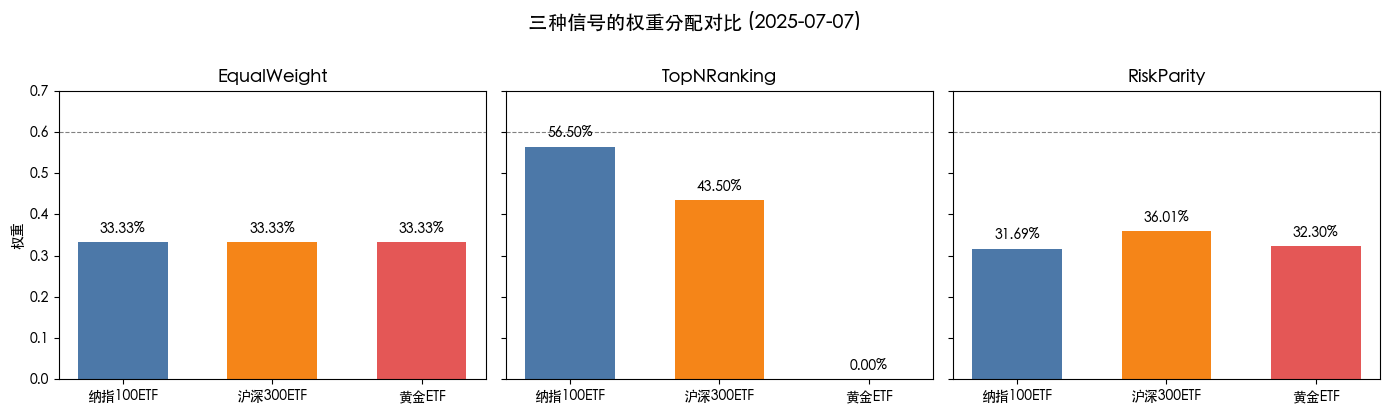

In [5]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 注册 macOS 系统中文字体，使 matplotlib 能正确渲染中文
for _font_path in [
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]:
    fm.fontManager.addfont(_font_path)
plt.rcParams["font.sans-serif"] = ["Heiti TC"] + plt.rcParams["font.sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# 选取一个有效日期（指标预热完成后）
valid_dates = ew_df.dropna().index
sample_date = valid_dates[len(valid_dates) // 2]  # 取中间点

names = [SYMBOL_NAMES[s] for s in SYMBOLS]
ew_vals = [ew_weights[s].loc[sample_date] for s in SYMBOLS]
tn_vals = [tn_weights[s].loc[sample_date] for s in SYMBOLS]
rp_vals = [rp_weights[s].loc[sample_date] for s in SYMBOLS]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = ["#4C78A8", "#F58518", "#E45756"]

for ax, vals, title in zip(
    axes,
    [ew_vals, tn_vals, rp_vals],
    ["EqualWeight", "TopNRanking", "RiskParity"],
):
    bars = ax.bar(names, vals, color=colors, width=0.6)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 0.7)
    ax.axhline(y=0.6, color="gray", linestyle="--", linewidth=0.8, label="max_weight")
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.02,
            f"{val:.2%}",
            ha="center",
            fontsize=10,
        )

axes[0].set_ylabel("权重")
fig.suptitle(f"三种信号的权重分配对比 ({sample_date.date()})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. 权重时序对比

权重快照只是某一天的截面。不同信号在时间维度上的权重变化模式也很不同：

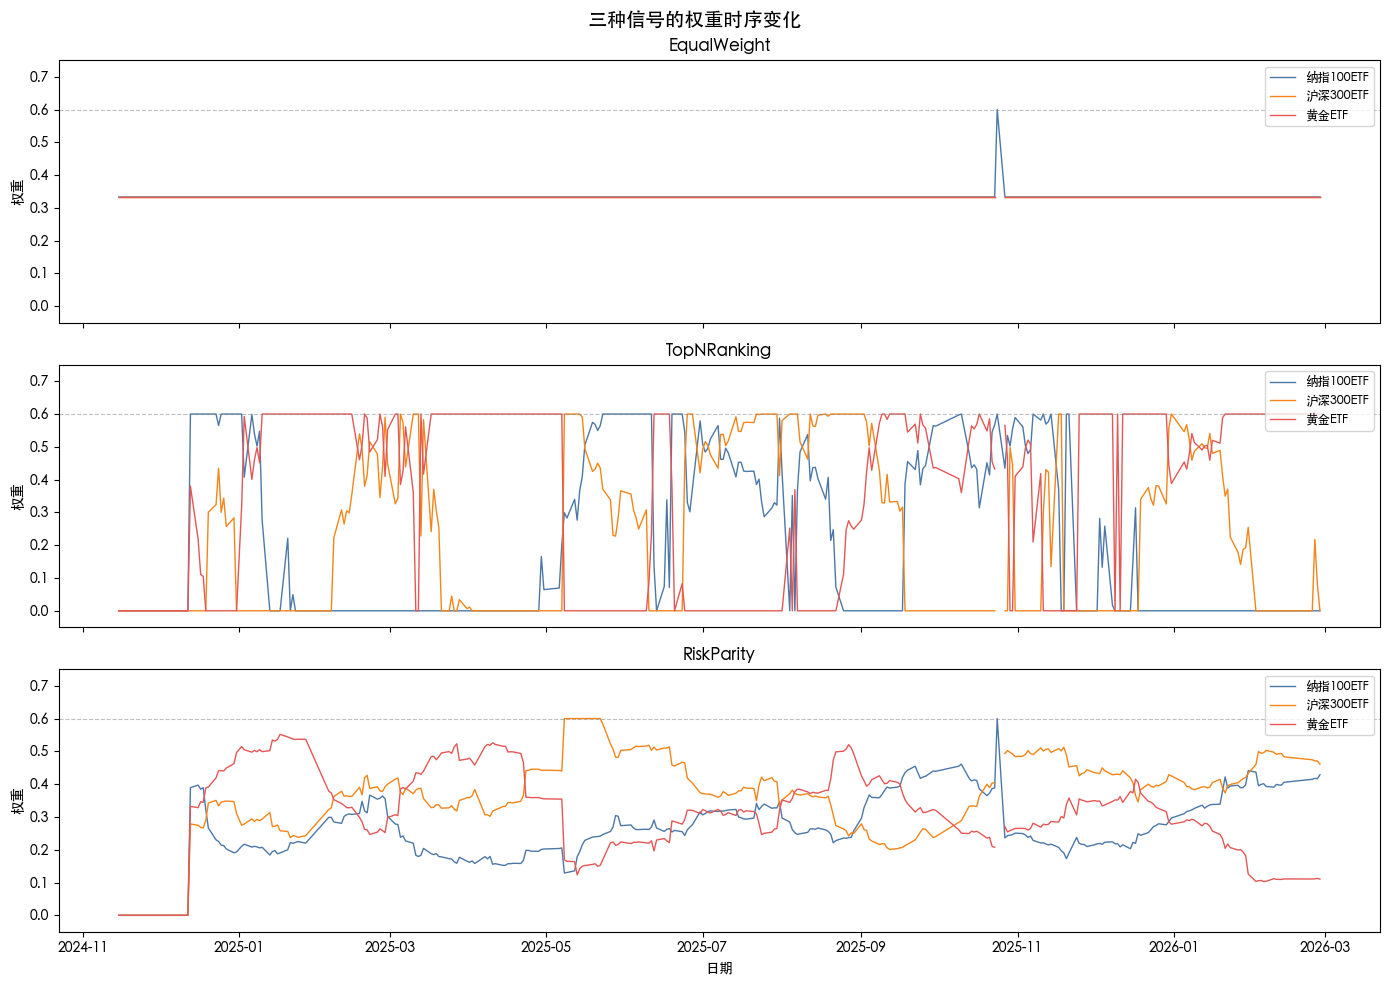

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
signal_data = [
    ("EqualWeight", ew_df),
    ("TopNRanking", tn_df),
    ("RiskParity", rp_df),
]
line_colors = {"纳指100ETF": "#4C78A8", "沪深300ETF": "#F58518", "黄金ETF": "#E45756"}

for ax, (title, df) in zip(axes, signal_data):
    for col in df.columns:
        ax.plot(df.index, df[col], label=col, color=line_colors[col], linewidth=1)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("权重")
    ax.set_ylim(-0.05, 0.75)
    ax.axhline(y=0.6, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("日期")
fig.suptitle("三种信号的权重时序变化", fontsize=14)
plt.tight_layout()
plt.show()

观察：
- **EqualWeight** 权重线完全平坦（每只始终 1/3 ≈ 33.3%），没有任何主动调整
- **TopNRanking** 权重跳跃最大——排名变化时某只 ETF 可能从 60% 直接降到 0%
- **RiskParity** 权重平滑变化——波动率是连续的，所以权重也连续调整

这三种模式分别对应了**无观点 → 强观点 → 风险均衡**的投资哲学。

---
## 5. 完整回测对比

将三种信号嵌入完整策略，固定 10 天调仓频率，跑完整回测：

In [ ]:
from oxq.core import Engine, Strategy
from oxq.rules import RebalanceRule
from oxq.trade import SimBroker
from oxq.universe import StaticUniverse

INITIAL_CASH = 100_000.0

COMMON = dict(
    hypothesis="对比等权、归一化排名、风险平价三种信号方法",
    objectives={
        "annualized_return": {"min": 0.05},
        "sharpe_ratio": {"min": 0.5},
        "max_drawdown": {"min": -0.20},
    },
    benchmarks=[],
    universe=StaticUniverse(SYMBOLS),
    indicators={
        "mom": (Momentum(), {"column": "close", "period": 20}),
        "vol": (RollingVolatility(), {"column": "close", "period": 20}),
        "ram": (Ratio(), {"col_a": "mom", "col_b": "vol"}),
    },
    entry_rules=[],
    exit_rules=[],
    rebalance_rules=[RebalanceRule(weight_col="tw", frequency=10)],
)

STRATEGIES = {
    "等权": Strategy(
        name="equal_weight",
        signals={"tw": (EqualWeight(), {"max_weight": 0.6})},
        **COMMON,
    ),
    "归一化": Strategy(
        name="top_n_ranking",
        signals={"tw": (TopNRanking(), {"score": "ram", "n": 2, "max_weight": 0.6})},
        **COMMON,
    ),
    "风险平价": Strategy(
        name="risk_parity",
        signals={"tw": (RiskParity(), {"vol": "vol", "max_weight": 0.6})},
        **COMMON,
    ),
}

results = {}
for label, strategy in STRATEGIES.items():
    broker = SimBroker()
    result = Engine().run(
        strategy,
        market=LocalMarketDataProvider(),
        broker=broker,
        start=START,
        end=END,
        initial_cash=INITIAL_CASH,
    )
    results[label] = result
    print(f"{label}: 总收益={result.total_return():.2%}, 交易={len(result.trades)}笔")

## 6. 净值曲线对比

先看收益——三种信号的累计收益是否有显著差异？

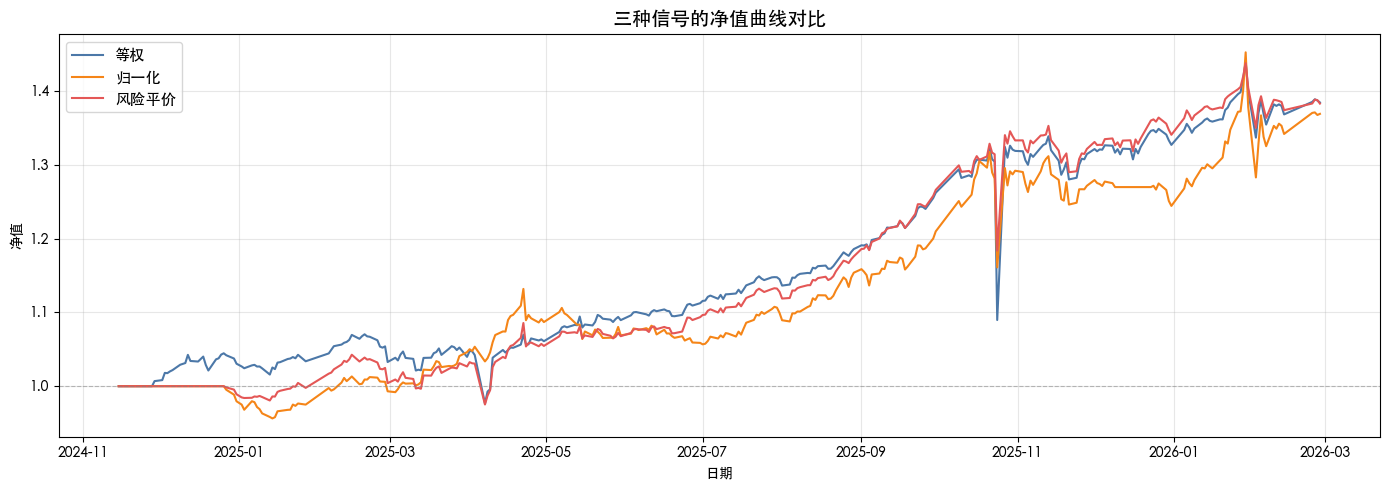

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
line_style = {
    "等权": {"color": "#4C78A8", "linestyle": "-"},
    "归一化": {"color": "#F58518", "linestyle": "-"},
    "风险平价": {"color": "#E45756", "linestyle": "-"},
}

for label, result in results.items():
    dates = [t for t, _ in result.equity_curve]
    values = [v / INITIAL_CASH for _, v in result.equity_curve]  # 归一化为净值
    ax.plot(dates, values, label=label, linewidth=1.5, **line_style[label])

ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_title("三种信号的净值曲线对比", fontsize=14)
ax.set_ylabel("净值")
ax.set_xlabel("日期")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 最大回撤曲线对比

净值曲线看起来走势相近？再看回撤曲线——差异立刻显现：

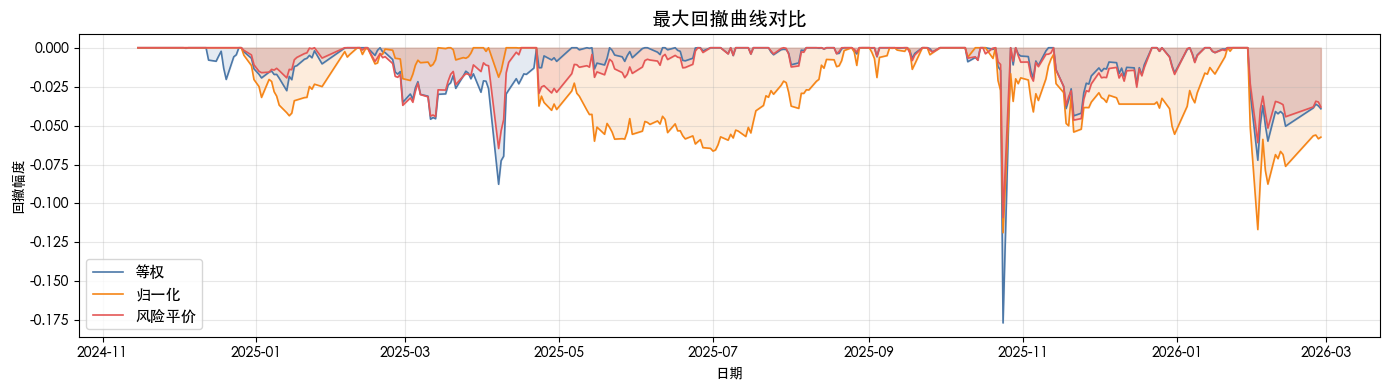

In [9]:
import numpy as np

fig, ax = plt.subplots(figsize=(14, 4))

for label, result in results.items():
    dates = [t for t, _ in result.equity_curve]
    values = np.array([v for _, v in result.equity_curve], dtype=float)
    peak = np.maximum.accumulate(values)
    drawdown = (values - peak) / peak
    ax.fill_between(dates, drawdown, 0, alpha=0.15, **{"color": line_style[label]["color"]})
    ax.plot(dates, drawdown, label=label, linewidth=1.2, color=line_style[label]["color"])

ax.set_title("最大回撤曲线对比", fontsize=14)
ax.set_ylabel("回撤幅度")
ax.set_xlabel("日期")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 关键发现：收益相近，风险迥异

结合净值曲线和回撤曲线，可以看到一个重要现象：

**三种信号的累计收益率相差不大，但最大回撤和波动率差异显著。**

- **TopNRanking** 集中持仓导致回撤最深——当重仓标的大幅下跌时，组合首当其冲
- **EqualWeight** 虽然分散，但对高波动资产没有降权，回撤仍然较大
- **RiskParity** 自动降低高波动资产的权重，回撤曲线最浅、最平滑

这正是风险平价策略的核心优势：**不靠选对方向赚更多，而是靠控制风险亏更少**。
反映到风险调整指标上，RiskParity 的 Sharpe Ratio 和 Calmar Ratio 通常优于另外两种方案。

换句话说：如果你只看收益率，三种信号似乎差别不大；但加上波动率和回撤的维度，差异立刻显现。
这也是为什么实际资产配置中，风险平价是最受欢迎的权重方案之一。

## 8. 指标对比表

重点关注：年化收益率是否接近？波动率和最大回撤的差距有多大？Sharpe 差异是否显著？

In [10]:
metrics = [
    ("总收益率", lambda r: f"{r.total_return():.2%}"),
    ("年化收益率", lambda r: f"{r.annualized_return():.2%}"),
    ("年化波动率", lambda r: f"{r.annualized_volatility():.2%}"),
    ("Sharpe Ratio", lambda r: f"{r.sharpe_ratio():.2f}"),
    ("Calmar Ratio", lambda r: f"{r.calmar_ratio():.2f}"),
    ("Sortino Ratio", lambda r: f"{r.sortino_ratio():.2f}"),
    ("最大回撤", lambda r: f"{r.max_drawdown():.2%}"),
    ("交易次数", lambda r: f"{len(r.trades)}"),
    ("期末资产", lambda r: f"{r.equity_curve[-1][1]:,.0f}"),
]

header = f"{'指标':>16}" + "".join(f"{label:>14}" for label in results)
print(header)
print("-" * len(header))
for name, fn in metrics:
    vals = "".join(f"{fn(r):>14}" for r in results.values())
    print(f"{name:>16}{vals}")

              指标            等权           归一化          风险平价
----------------------------------------------------------
            总收益率        38.47%        36.93%        38.32%
           年化收益率        26.55%        25.63%        26.46%
           年化波动率        27.41%        20.60%        19.15%
    Sharpe Ratio          1.09          1.35          1.47
    Calmar Ratio          1.50          2.16          2.43
   Sortino Ratio          0.89          1.14          1.24
            最大回撤       -17.68%       -11.88%       -10.91%
            交易次数            93            64            87
            期末资产       138,473       136,928       138,321


## 9. 目标检查

In [11]:
objectives = COMMON["objectives"]
metric_fns = {
    "annualized_return": lambda r: r.annualized_return(),
    "sharpe_ratio": lambda r: r.sharpe_ratio(),
    "max_drawdown": lambda r: r.max_drawdown(),
}

for label, result in results.items():
    checks = []
    for metric_name, bounds in objectives.items():
        actual = metric_fns[metric_name](result)
        passed = True
        if "min" in bounds:
            passed = passed and actual >= bounds["min"]
        if "max" in bounds:
            passed = passed and actual <= bounds["max"]
        tag = "pass" if passed else "FAIL"
        checks.append(f"{tag} {metric_name}")
    print(f"  {label:<8} {'  '.join(checks)}")

  等权       pass annualized_return  pass sharpe_ratio  pass max_drawdown
  归一化      pass annualized_return  pass sharpe_ratio  pass max_drawdown
  风险平价     pass annualized_return  pass sharpe_ratio  pass max_drawdown


---
## 10. 总结：如何选择 Signal？

### 核心结论

**三种信号的累计收益率相差不大，但风险特征截然不同。**

回测结果验证了一个经典的资产配置结论：权重分配方法对收益的影响有限，但对波动率、最大回撤和 Sharpe Ratio 的影响巨大。这正是选择信号方法时最应该关注的维度。

### 三种信号的核心区别

| 维度 | EqualWeight | TopNRanking | RiskParity |
|------|-------------|-------------|------------|
| **隐含假设** | 所有资产前景相同 | 强动量资产更优 | 波动率可预测风险 |
| **集中度** | 最分散 | 最集中 | 中等 |
| **换手率** | 最低（权重不变） | 最高（排名变化） | 中等（波动率平滑） |
| **波动率** | 中等 | 最高 | **最低** |
| **最大回撤** | 中等 | 最深 | **最浅** |
| **Sharpe** | 中等 | 受集中度拖累 | **通常最优** |

### 选择建议

- **EqualWeight** — 作为 baseline，或在没有好的因子时使用。也适合懒人定投场景
- **TopNRanking** — 当你有一个可靠的评分因子（如风险调整动量），并且愿意承受集中持仓带来的高波动和深回撤
- **RiskParity** — 追求风险均衡、控制回撤。在收益差不多的前提下，用更小的波动和更浅的回撤换取更高的风险调整收益（Sharpe / Calmar）

### 组合使用

实际策略中，这些信号可以互相对照：
- 用 EqualWeight 作为 benchmark，衡量主动信号是否创造了超额收益
- TopNRanking 和 RiskParity 可以混合使用（如先按动量筛选，再按风险平价分配权重）

### 延伸阅读

- `rotation_strategy` 教程 — 深入 TopNRanking 和 RebalanceRule 的细节
- `examples/strategies/signal_comparison.py` — 本教程的脚本版本